In [8]:
!pip install xmltodict

In [10]:
import xmltodict  # XML을 딕셔너리로 바꿔주는 라이브러리
import requests
import pandas as pd
import json

# 1. API 설정
api_key = "663c9e65449b13834dbba27c3cd63d6449181fee65c69ff348dc4c41fc959e42"
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"

params = {
    'serviceKey' : api_key ,
    'numOfRows' : '100',
    'pageNo' : '1',
    'zcode' : '29',
}

# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)

dict_data = xmltodict.parse(response.content)

dict_data

# 3. DataFrame으로 변환
items = dict_data['response']['body']['items']['item'] 
# 6. DataFrame 변환 
df = pd.DataFrame(items) 

df.head()


,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,한국광기술원,ME181501,01,06,광주광역시 북구 첨단 벤처로 108번길 9,null,null,35.231341167,126.85982174,24시간 이용가능,...,None,N,None,N,None,N,2018,1,F,시그넷
1,롯데마트 수완점,ME181545,01,06,광주광역시 광산구 장신로 98,null,null,35.190126,126.820343,10:00~23:00,...,None,N,None,N,None,N,2018,5,F,시그넷
2,롯데마트 수완점,ME181545,11,06,광주광역시 광산구 장신로 98,null,null,35.190126,126.820343,10:00~23:00,...,None,N,None,N,None,N,2018,5,F,시그넷
3,블루핸즈 하남현대자동차서비스,ME183018,01,06,광주광역시 광산구 하남대로 127-10,null,null,35.1810177,126.8074485,24시간 이용가능,...,None,N,None,N,None,N,2018,1,F,채비
4,기아자동차 진월점,ME183019,01,06,광주광역시 남구 진월동 314-1,null,null,35.124734,126.8971093,24시간 이용가능,...,None,N,None,N,None,N,2018,1,F,채비


In [18]:

# 1. 수집된 데이터의 shape과 실제 데이터 출력

# 2. 분석에 필요한 핵심 컬럼만 선택
# # statNm: 충전소명, addr: 주소, chgerType: 충전기 타입, useTime: 이용시간
df = df[['statNm', 'chgerType', 'addr', 'useTime' ]]
df
# 3. 결측치(NaN) 확인 및 처리
df.info()
# 4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

# ** 특성공학
# 1. 주소 데이터에서 '시/도' 파생 변수 생성
# # 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출

# # 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# # 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일

# 2. 충전기 타입 범주화
# # API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타


# 3. 24시간 이용 가능 여부 파생 변수 생성
# # 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환


# ** 시각화
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)

# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)

# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

# ** 도출 인사이트

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statNm     100 non-null    object
 1   chgerType  100 non-null    object
 2   addr       100 non-null    object
 3   useTime    100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [19]:
df = df.rename(columns={
    'statNm': '충전소명',
    'chgerType': '충전기타입',
    'addr': '주소',
    'useTime': '이용가능시간'
})

df

,충전소명,충전기타입,주소,이용가능시간
0,한국광기술원,06,광주광역시 북구 첨단 벤처로 108번길 9,24시간 이용가능
1,롯데마트 수완점,06,광주광역시 광산구 장신로 98,10:00~23:00
2,롯데마트 수완점,06,광주광역시 광산구 장신로 98,10:00~23:00
3,블루핸즈 하남현대자동차서비스,06,광주광역시 광산구 하남대로 127-10,24시간 이용가능
4,기아자동차 진월점,06,광주광역시 남구 진월동 314-1,24시간 이용가능
...,...,...,...,...
95,영산강유역환경청 내,04,광주광역시 서구 계수로 31,24시간 이용가능
96,영산강유역환경청 내,04,광주광역시 서구 계수로 31,24시간 이용가능
97,영산강유역환경청 내,04,광주광역시 서구 계수로 31,24시간 이용가능
98,광주송정역 뒤 공영주차장,04,광주광역시 광산구 송정동 1007-4,24시간 이용가능


In [30]:
# 4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)
df = df.drop_duplicates(subset='충전소명')
df
# ** 특성공학
# 1. 주소 데이터에서 '시/도' 파생 변수 생성
# # 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df['시/도'] = df['주소'].str.split().str[1]
df
# # 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# # 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
df['시/도'] = df['시/도'].str[:3]
df
# 2. 충전기 타입 범주화
# # API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
df['충전기타입기능'] = df['충전기타입'].map({
    '01': '완속',
    '03': '급속',
    '06': '초급속'
}).fillna('기타')
df


# 3. 24시간 이용 가능 여부 파생 변수 생성
# # 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
df['24시간가능'] = df['이용가능시간'].str[:4] == '24시간'
df

# ** 시각화
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)

# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)

# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

# ** 도출 인사이트

,충전소명,충전기타입,주소,이용가능시간,시/도,충전기타입기능,24시간가능
0,한국광기술원,06,광주광역시 북구 첨단 벤처로 108번길 9,24시간 이용가능,북구,초급속,True
1,롯데마트 수완점,06,광주광역시 광산구 장신로 98,10:00~23:00,광산구,초급속,False
3,블루핸즈 하남현대자동차서비스,06,광주광역시 광산구 하남대로 127-10,24시간 이용가능,광산구,초급속,True
4,기아자동차 진월점,06,광주광역시 남구 진월동 314-1,24시간 이용가능,남구,초급속,True
5,이마트 광산점,06,광주광역시 광산구 사암로 172,10:00~24:00,광산구,초급속,False
...,...,...,...,...,...,...,...
90,한국토지주택공사 광주전남지역본부,04,광주광역시 서구 시청로 91,08:00~20:00,서구,기타,False
92,상무시민공원,04,광주광역시 서구 치평동 1162,24시간 이용가능,서구,기타,True
94,영산강유역환경청 내,04,광주광역시 서구 계수로 31,24시간 이용가능,서구,기타,True
98,광주송정역 뒤 공영주차장,04,광주광역시 광산구 송정동 1007-4,24시간 이용가능,광산구,기타,True


In [16]:
df.shape

(100, 4)

In [33]:
지역별충전소갯수 = df.groupby('시/도')['충전소명'].count()
지역별충전소갯수

시/도
광산구    21
남구      8
동구      9
북구     15
서구     15
Name: 충전소명, dtype: int64

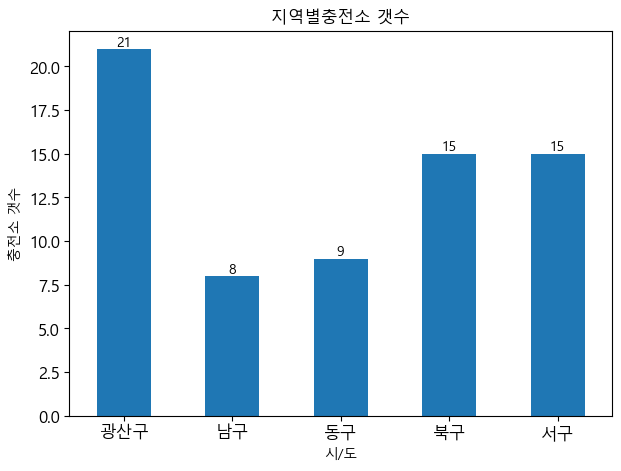

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


지역별충전소갯수.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('지역별충전소 갯수')
plt.ylabel('충전소 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [40]:
충전기타입비율 = df['충전기타입기능'].value_counts()

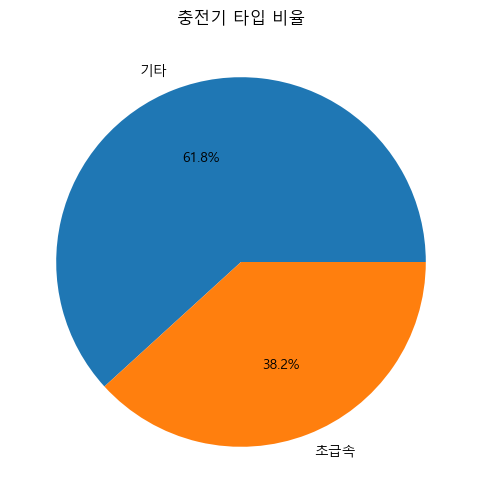

In [41]:
충전기타입비율.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title('충전기 타입 비율')
plt.ylabel('')

plt.show()

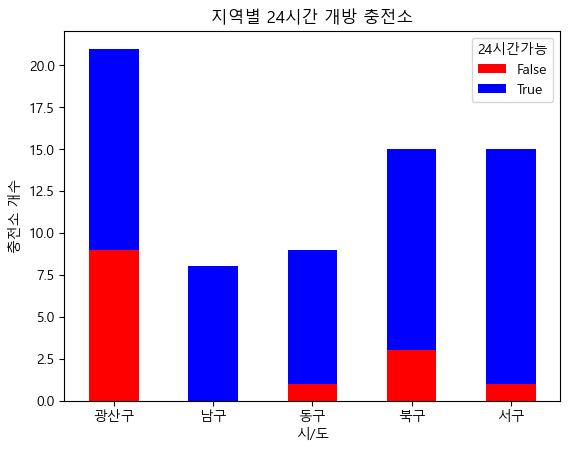

In [47]:
지역24 = df.groupby(['시/도','24시간가능']).size().unstack()

지역24.plot(kind='bar', stacked=True, color=['red','blue'])

plt.title('지역별 24시간 개방 충전소')
plt.ylabel('충전소 개수')
plt.xticks(rotation=0)

plt.show()

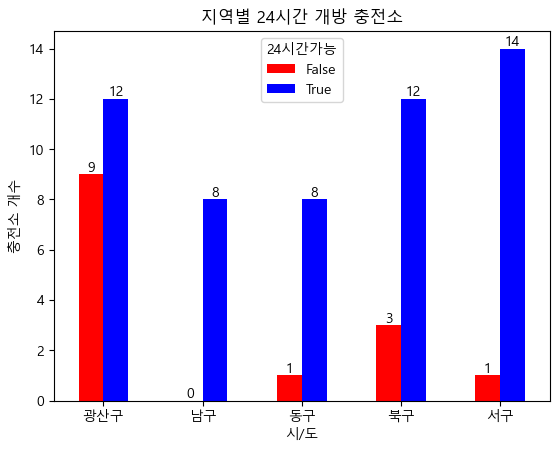

In [50]:
지역24 = df.groupby(['시/도','24시간가능']).size().unstack()

지역24.plot(kind='bar', color=['red','blue'])

plt.title('지역별 24시간 개방 충전소')
plt.ylabel('충전소 개수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()